# Gemini-Guided Pick and Place

This notebook keeps the workspace calibration and robot motion flow from `pick_and_place.ipynb`, but replaces ArUco-based object selection with the Gemini API pattern from `gemini.ipynb`.

Supported prompt styles:
- `Describe the scene and identify the objects in it.`
- `Pick up the grey cube.`
- `Pick up the grey cube and place it next to the smartphone on the left.`

Calibration still uses ArUco markers `0,1,2,3,4`.
Object detection, task classification, and source/destination selection now come from the Gemini response.


In [9]:
import io
import json
import math
import os
import re
import time

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pyrealsense2 as rs
from PIL import Image
from dynamixel_sdk import *
from google import genai
from google.genai import types


In [11]:
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
if not GEMINI_API_KEY:
    raise ValueError("Set GEMINI_API_KEY in your environment before running this notebook.")

GEMINI_MODEL = "gemini-robotics-er-1.6-preview"

ROBOT_BASE_FORWARD_OFFSET = 0.000
ROBOT_BASE_LATERAL_OFFSET = 0.000
ROBOT_BASE_VERTICAL_OFFSET = 0.000

SYSTEM_PROMPT = """
You are the perception and planning module for a 4-DOF OpenManipulator-X robot.
You receive one RGB image and one user instruction.
Decide whether the instruction is a scene description, pickup task, or pick_and_place task.

Return JSON only. Do not wrap the answer in markdown.

Output schema:
{
  "task": "describe" | "pickup" | "pick_and_place",
  "detections": [
    {
      "label": "string",
      "center": {"Y": int, "X": int},
      "bounding_box": [ymin, xmin, ymax, xmax]
    }
  ],
  "description": "string or null",
  "source": {"Y": int, "X": int} or null,
  "destination": {"Y": int, "X": int} or null,
  "trajectory": [{"Y": int, "X": int}, ...] or null
}

Rules:
- All coordinates must be integers normalized from 0 to 1000.
- Limit detections to at most 15 objects.
- For "pickup", identify the target object and fill "source".
- For "pick_and_place", identify the target object, fill "source", choose a collision-aware destination that satisfies the instruction, and return 15 trajectory points from source to destination.
- For "describe", fill "detections" and "description" only.
- Prefer the graspable center of the object for "source".
- If an object is partly occluded, estimate its center from visible geometry.
- Keep the destination clear of nearby objects when the instruction says "next to", "beside", or "on".
"""

client = genai.Client(api_key=GEMINI_API_KEY)


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [12]:
def init_realsense():
    pipeline = rs.pipeline()
    config = rs.config()
    config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
    config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)

    profile = pipeline.start(config)
    align = rs.align(rs.stream.color)
    intrinsics = profile.get_stream(rs.stream.color).as_video_stream_profile().get_intrinsics()
    return pipeline, align, intrinsics


def get_frames(pipeline, align):
    frames = pipeline.wait_for_frames()
    aligned_frames = align.process(frames)
    color_frame = aligned_frames.get_color_frame()
    depth_frame = aligned_frames.get_depth_frame()

    if not color_frame or not depth_frame:
        return None, None

    color_image = np.asanyarray(color_frame.get_data())
    return color_image, depth_frame


def capture_live_scene(pipeline, align, warmup_frames=15):
    color_image, depth_frame = None, None
    for _ in range(warmup_frames):
        color_image, depth_frame = get_frames(pipeline, align)
    if color_image is None or depth_frame is None:
        raise RuntimeError("Failed to capture aligned RealSense frames.")
    return color_image, depth_frame


def init_aruco():
    try:
        aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
        detector_params = cv2.aruco.DetectorParameters()
        detector = cv2.aruco.ArucoDetector(aruco_dict, detector_params)
        return detector_params, aruco_dict, detector, False
    except AttributeError:
        aruco_dict = cv2.aruco.Dictionary_get(cv2.aruco.DICT_4X4_50)
        detector_params = cv2.aruco.DetectorParameters_create()
        return detector_params, aruco_dict, None, True


def detect_markers(image, aruco_dict, detector, opencv_old, detector_params):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if opencv_old:
        corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=detector_params)
    else:
        corners, ids, _ = detector.detectMarkers(gray)
    return corners, ids


def get_smoothed_depth(depth_frame, u, v, radius=2):
    values = []
    height = depth_frame.get_height()
    width = depth_frame.get_width()
    for dv in range(-radius, radius + 1):
        for du in range(-radius, radius + 1):
            uu = max(0, min(width - 1, u + du))
            vv = max(0, min(height - 1, v + dv))
            depth_value = depth_frame.get_distance(uu, vv)
            if depth_value > 0:
                values.append(depth_value)
    if not values:
        return 0.0
    return float(np.median(values))


def normalize_vector(vec):
    norm = np.linalg.norm(vec)
    if norm < 1e-9:
        return None
    return vec / norm


def project_point_to_plane(point, plane_point, plane_normal):
    return point - np.dot(point - plane_point, plane_normal) * plane_normal


def get_marker_center_camera_point(corners, ids, marker_id, depth_frame, intrinsics):
    if ids is None:
        return None

    detected_ids = ids.flatten().tolist()
    if marker_id not in detected_ids:
        return None

    idx = detected_ids.index(marker_id)
    marker_corners = corners[idx][0]
    u = int(np.mean(marker_corners[:, 0]))
    v = int(np.mean(marker_corners[:, 1]))
    depth_value = get_smoothed_depth(depth_frame, u, v)
    if depth_value <= 0:
        return None

    point = rs.rs2_deproject_pixel_to_point(intrinsics, [u, v], depth_value)
    return np.array(point, dtype=np.float32)


def build_robot_frame(corners, ids, depth_frame, intrinsics):
    required_ids = [0, 1, 2, 3, 4]
    marker_points = {}
    for marker_id in required_ids:
        point = get_marker_center_camera_point(corners, ids, marker_id, depth_frame, intrinsics)
        if point is None:
            return None, f"missing 3D point for marker {marker_id}"
        marker_points[marker_id] = point

    p0 = marker_points[0]
    p1 = marker_points[1]
    p2 = marker_points[2]
    p3 = marker_points[3]
    p4 = marker_points[4]

    board_right = normalize_vector(p1 - p0)
    board_forward_raw = p3 - p0
    board_forward_raw = board_forward_raw - np.dot(board_forward_raw, board_right) * board_right
    board_forward = normalize_vector(board_forward_raw)
    if board_right is None or board_forward is None:
        return None, "failed to build board axes"

    board_up = normalize_vector(np.cross(board_forward, board_right))
    if board_up is None:
        return None, "failed to build board normal"

    workspace_center = 0.25 * (p0 + p1 + p2 + p3)
    if np.dot(p4 - workspace_center, board_up) < 0:
        board_up = -board_up

    base_projection = project_point_to_plane(p4, p0, board_up)
    origin = (
        base_projection
        + ROBOT_BASE_FORWARD_OFFSET * board_forward
        + ROBOT_BASE_LATERAL_OFFSET * board_right
        + ROBOT_BASE_VERTICAL_OFFSET * board_up
    )

    return {
        "origin": origin,
        "x_axis": board_forward,
        "y_axis": board_right,
        "z_axis": board_up,
        "workspace_center": workspace_center,
        "base_marker_center": p4,
    }, None


def average_robot_frames(frames):
    if not frames:
        return None

    def avg_vec(key):
        return np.mean([frame[key] for frame in frames], axis=0)

    x_axis = normalize_vector(avg_vec("x_axis"))
    if x_axis is None:
        return None

    y_axis_seed = avg_vec("y_axis")
    y_axis_seed = y_axis_seed - np.dot(y_axis_seed, x_axis) * x_axis
    y_axis = normalize_vector(y_axis_seed)
    if y_axis is None:
        return None

    z_axis = normalize_vector(np.cross(x_axis, y_axis))
    if z_axis is None:
        return None

    y_axis = normalize_vector(np.cross(z_axis, x_axis))
    if y_axis is None:
        return None

    return {
        "origin": avg_vec("origin"),
        "x_axis": x_axis,
        "y_axis": y_axis,
        "z_axis": z_axis,
        "workspace_center": avg_vec("workspace_center"),
        "base_marker_center": avg_vec("base_marker_center"),
    }


def calibrate_workspace(pipeline, align, intrinsics, detector_params, aruco_dict, detector, opencv_old, stable_frames=8):
    print("Calibrating workspace. Keep markers 0,1,2,3,4 clearly visible...")
    collected_frames = []
    last_count = -1

    while True:
        color_image, depth_frame = get_frames(pipeline, align)
        if color_image is None:
            continue

        corners, ids = detect_markers(color_image, aruco_dict, detector, opencv_old, detector_params)
        display_image = color_image.copy()
        if ids is not None:
            cv2.aruco.drawDetectedMarkers(display_image, corners, ids)
        cv2.imshow("Camera Feed - Workspace Calibration", display_image)
        cv2.waitKey(1)

        robot_frame, frame_error = build_robot_frame(corners, ids, depth_frame, intrinsics)
        if robot_frame is None:
            if last_count != 0:
                print(f"Calibration waiting: {frame_error}.")
                last_count = 0
            collected_frames.clear()
            continue

        collected_frames.append(robot_frame)
        if len(collected_frames) > stable_frames:
            collected_frames.pop(0)

        if len(collected_frames) != last_count:
            print(f"Calibration progress: {len(collected_frames)}/{stable_frames} stable frames")
            last_count = len(collected_frames)

        if len(collected_frames) >= stable_frames:
            calibrated_frame = average_robot_frames(collected_frames)
            if calibrated_frame is None:
                collected_frames.clear()
                last_count = 0
                print("Calibration rejected because the averaged frame was invalid. Retrying...")
                continue

            print("Workspace calibration locked.")
            print(f"Origin: {[round(v, 3) for v in calibrated_frame['origin']]}")
            print(f"X axis: {[round(v, 3) for v in calibrated_frame['x_axis']]}")
            print(f"Y axis: {[round(v, 3) for v in calibrated_frame['y_axis']]}")
            print(f"Z axis: {[round(v, 3) for v in calibrated_frame['z_axis']]}")
            return calibrated_frame


def pixel_to_camera(u, v, depth_meters, intrinsics):
    point = rs.rs2_deproject_pixel_to_point(intrinsics, [u, v], depth_meters)
    return np.array(point, dtype=np.float32)


def transform_camera_to_robot(point_camera, robot_frame):
    delta = point_camera[:3] - robot_frame["origin"]
    return np.array([
        float(np.dot(delta, robot_frame["x_axis"])),
        float(np.dot(delta, robot_frame["y_axis"])),
        float(np.dot(delta, robot_frame["z_axis"])),
    ], dtype=np.float32)


In [13]:
def prepare_image_bytes(color_image, target_height=720):
    rgb_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_image)
    if pil_image.height != target_height:
        resample = Image.Resampling.LANCZOS if hasattr(Image, "Resampling") else Image.LANCZOS
        new_width = max(1, int(round(pil_image.width * target_height / pil_image.height)))
        pil_image = pil_image.resize((new_width, target_height), resample)

    buffer = io.BytesIO()
    pil_image.save(buffer, format="PNG")
    return buffer.getvalue()


def extract_json_payload(text):
    cleaned = text.strip()
    match = re.search(r"```(?:json)?\s*(.*?)\s*```", cleaned, flags=re.IGNORECASE | re.DOTALL)
    if match:
        cleaned = match.group(1).strip()
    else:
        brace_positions = [idx for idx in (cleaned.find("{"), cleaned.find("[")) if idx != -1]
        if brace_positions:
            start = min(brace_positions)
            end = max(cleaned.rfind("}"), cleaned.rfind("]"))
            if end >= start:
                cleaned = cleaned[start:end + 1]
    return json.loads(cleaned)


def run_gemini_task(color_image, task_prompt, verbose=True):
    image_bytes = prepare_image_bytes(color_image)
    response = client.models.generate_content(
        model=GEMINI_MODEL,
        contents=[
            SYSTEM_PROMPT,
            task_prompt,
            types.Part.from_bytes(data=image_bytes, mime_type="image/png"),
        ],
        config=types.GenerateContentConfig(
            temperature=0.2,
            thinking_config=types.ThinkingConfig(thinking_budget=0),
        ),
    )
    plan = extract_json_payload(response.text)
    if verbose:
        print(json.dumps(plan, indent=2))
    return plan


def point_to_yx(point):
    if point is None:
        return None

    y_value = point.get("Y", point.get("y"))
    x_value = point.get("X", point.get("x"))
    if y_value is None or x_value is None:
        return None

    return int(round(float(y_value))), int(round(float(x_value)))


def normalized_to_pixel(point, width, height):
    yx = point_to_yx(point)
    if yx is None:
        return None

    y_norm, x_norm = yx
    x_norm = int(np.clip(x_norm, 0, 1000))
    y_norm = int(np.clip(y_norm, 0, 1000))
    u = int(round(x_norm * (width - 1) / 1000.0))
    v = int(round(y_norm * (height - 1) / 1000.0))
    return u, v


def first_detection_center(plan):
    detections = plan.get("detections") or []
    if not detections:
        return None
    return detections[0].get("center")


def get_source_point(plan):
    return plan.get("source") or first_detection_center(plan)


def get_destination_point(plan):
    return plan.get("destination")


def plot_plan_on_image(color_image, response_json):
    image_rgb = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    dpi = 100
    fig, ax = plt.subplots(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax.imshow(image_rgb, interpolation="nearest")

    for item in response_json.get("detections", []):
        point = item.get("center")
        label = item.get("label", "object")
        bbox = item.get("bounding_box")

        pixel = normalized_to_pixel(point, w, h)
        if pixel is not None:
            u, v = pixel
            ax.add_patch(patches.Circle((u, v), radius=12, color="red"))
            ax.text(u + 14, v - 14, label, color="red", fontsize=8, backgroundcolor="white")

        if bbox and len(bbox) == 4:
            ymin, xmin, ymax, xmax = bbox
            ymin_px = float(ymin) * (h - 1) / 1000.0
            xmin_px = float(xmin) * (w - 1) / 1000.0
            ymax_px = float(ymax) * (h - 1) / 1000.0
            xmax_px = float(xmax) * (w - 1) / 1000.0
            ax.add_patch(
                patches.Rectangle(
                    (xmin_px, ymin_px),
                    xmax_px - xmin_px,
                    ymax_px - ymin_px,
                    fill=False,
                    color="green",
                    linewidth=3,
                )
            )

    source_pixel = normalized_to_pixel(get_source_point(response_json), w, h)
    if source_pixel is not None:
        u, v = source_pixel
        ax.add_patch(patches.Circle((u, v), radius=12, color="blue"))
        ax.text(u + 24, v + 24, "Source", color="blue", fontsize=8, backgroundcolor="white")

    destination_pixel = normalized_to_pixel(get_destination_point(response_json), w, h)
    if destination_pixel is not None:
        u, v = destination_pixel
        ax.add_patch(patches.Circle((u, v), radius=12, color="purple"))
        ax.text(u + 24, v + 24, "Destination", color="purple", fontsize=8, backgroundcolor="white")

    trajectory_points = response_json.get("trajectory") or []
    trajectory_pixels = []
    for point in trajectory_points:
        pixel = normalized_to_pixel(point, w, h)
        if pixel is not None:
            trajectory_pixels.append(pixel)

    if len(trajectory_pixels) >= 2:
        trajectory_pixels = np.array(trajectory_pixels)
        ax.plot(trajectory_pixels[:, 0], trajectory_pixels[:, 1], color="orange", linewidth=3, label="Trajectory")
        ax.legend()

    ax.set_axis_off()
    plt.tight_layout(pad=0)
    plt.show()

    print(f"Task: {response_json.get('task')}")
    if response_json.get("description"):
        print(f"Description: {response_json['description']}")


In [14]:
ARM_LINKS = {
    "base_height": -0.160,
    "shoulder": 0.130,
    "elbow": 0.135,
    "wrist": 0.060,
}
JOINT_OFFSET_RAD = math.atan2(0.024, 0.128)


def inverse_kinematics(x, y, z):
    l1 = ARM_LINKS["base_height"]
    l2 = ARM_LINKS["shoulder"]
    l3 = ARM_LINKS["elbow"]
    l4 = ARM_LINKS["wrist"]

    joint1 = math.atan2(y, x)
    r = math.sqrt(x ** 2 + y ** 2)
    z_prime = z - l1

    wrist_r = r - l4
    if wrist_r <= 0:
        return None

    reach = math.sqrt(wrist_r ** 2 + z_prime ** 2)
    min_reach = abs(l2 - l3) + 1e-6
    max_reach = (l2 + l3) - 1e-6
    if reach < min_reach or reach > max_reach:
        return None

    d_value = (wrist_r ** 2 + z_prime ** 2 - l2 ** 2 - l3 ** 2) / (2 * l2 * l3)
    d_value = max(-1.0, min(1.0, d_value))

    elbow_eff = math.atan2(math.sqrt(max(0.0, 1 - d_value ** 2)), d_value)
    shoulder_eff = math.atan2(z_prime, wrist_r) - math.atan2(
        l3 * math.sin(elbow_eff),
        l2 + l3 * math.cos(elbow_eff),
    )

    joint2 = shoulder_eff + JOINT_OFFSET_RAD
    joint3 = elbow_eff - JOINT_OFFSET_RAD
    joint4 = -(joint2 + joint3)
    return [joint1, joint2, joint3, joint4]


ADDR_TORQUE_ENABLE = 64
ADDR_GOAL_POSITION = 116
ADDR_PRESENT_POSITION = 132
PROTOCOL_VERSION = 2.0
BAUDRATE = 1000000
DEVICENAME = "COM9"
DXL_IDS = [11, 12, 13, 14, 15]
GRIPPER_OPEN_POS = 1500
GRIPPER_CLOSED_POS = 2300
DEFAULT_POS = {
    11: 2048,
    12: 1227,
    13: 2524,
    14: 2414,
    15: GRIPPER_OPEN_POS,
}


def init_dynamixel():
    port_handler = PortHandler(DEVICENAME)
    packet_handler = PacketHandler(PROTOCOL_VERSION)

    if not port_handler.openPort() or not port_handler.setBaudRate(BAUDRATE):
        return None, None

    for dxl_id in DXL_IDS:
        packet_handler.write1ByteTxRx(port_handler, dxl_id, ADDR_TORQUE_ENABLE, 1)
    return port_handler, packet_handler


def rad_to_dynamixel(angle):
    pos = int((angle + math.pi) * (4095.0 / (2 * math.pi)))
    return max(0, min(4095, pos))


def dynamixel_to_rad(pos):
    return (pos * (2 * math.pi) / 4095.0) - math.pi


def smooth_profile(t):
    return 0.5 * (1 - math.cos(math.pi * t))


def send_joint_positions(port_handler, packet_handler, q_positions):
    for i, dxl_id in enumerate([11, 12, 13, 14]):
        pos = rad_to_dynamixel(q_positions[i])
        packet_handler.write4ByteTxRx(port_handler, dxl_id, ADDR_GOAL_POSITION, pos)


def move_smooth(port_handler, packet_handler, q_start, q_goal, duration):
    steps = 80
    dt = duration / steps
    for step in range(steps + 1):
        t = step / steps
        alpha = smooth_profile(t)
        q = [qs + alpha * (qg - qs) for qs, qg in zip(q_start, q_goal)]
        send_joint_positions(port_handler, packet_handler, q)
        time.sleep(dt)


def set_gripper(port_handler, packet_handler, open_gripper=True):
    pos = GRIPPER_OPEN_POS if open_gripper else GRIPPER_CLOSED_POS
    packet_handler.write4ByteTxRx(port_handler, 15, ADDR_GOAL_POSITION, pos)


def read_positions(port_handler, packet_handler):
    positions = {}
    for dxl_id in DXL_IDS:
        pos, dxl_comm, dxl_err = packet_handler.read4ByteTxRx(port_handler, dxl_id, ADDR_PRESENT_POSITION)
        if dxl_comm == COMM_SUCCESS and dxl_err == 0:
            positions[dxl_id] = pos
    return positions


def set_default_positions(port_handler, packet_handler):
    print("Moving robot to default position using software interpolation...")
    current_positions = read_positions(port_handler, packet_handler)
    if not current_positions:
        print("Failed to read current positions. Moving directly to default...")
        for dxl_id, pos in DEFAULT_POS.items():
            packet_handler.write4ByteTxRx(port_handler, dxl_id, ADDR_GOAL_POSITION, pos)
        time.sleep(1.5)
        return

    steps = 50
    step_delay = 0.03
    increments = {}
    for dxl_id in DEFAULT_POS:
        if dxl_id in current_positions:
            increments[dxl_id] = (DEFAULT_POS[dxl_id] - current_positions[dxl_id]) / steps

    for step in range(1, steps + 1):
        for dxl_id in DEFAULT_POS:
            if dxl_id in increments:
                int_pos = int(current_positions[dxl_id] + (increments[dxl_id] * step))
                int_pos = max(0, min(4095, int_pos))
                packet_handler.write4ByteTxRx(port_handler, dxl_id, ADDR_GOAL_POSITION, int_pos)
        time.sleep(step_delay)


TARGET_FORWARD_OFFSET = 0.000
TARGET_LATERAL_OFFSET = 0.000
DEST_FORWARD_OFFSET = 0.000
DEST_LATERAL_OFFSET = 0.000
BOARD_PLANE_PICK_Z = 0.000
BOARD_PLANE_APPROACH_Z = 0.000
BOARD_PLANE_PLACE_Z = 0.000
BOARD_PLANE_PLACE_APPROACH_Z = 0.000
WORKSPACE_X_LIMITS = (0.10, 0.36)
WORKSPACE_Y_LIMIT = 0.20


def is_target_in_workspace(x, y):
    if x < WORKSPACE_X_LIMITS[0]:
        return False, f"x={x:.3f} is too close to the robot base"
    if x > WORKSPACE_X_LIMITS[1]:
        return False, f"x={x:.3f} is beyond the current workspace limit"
    if abs(y) > WORKSPACE_Y_LIMIT:
        return False, f"|y|={abs(y):.3f} is beyond the side-to-side limit"
    return True, "inside workspace"


def current_joint_radians(port_handler, packet_handler):
    curr_pos_dict = read_positions(port_handler, packet_handler)
    if not curr_pos_dict or not all(i in curr_pos_dict for i in [11, 12, 13, 14]):
        raise RuntimeError("Hardware missed a position read. Check the Dynamixels and retry.")

    return [
        dynamixel_to_rad(curr_pos_dict[11]),
        dynamixel_to_rad(curr_pos_dict[12]),
        dynamixel_to_rad(curr_pos_dict[13]),
        dynamixel_to_rad(curr_pos_dict[14]),
    ]


def default_joint_radians():
    return [
        dynamixel_to_rad(DEFAULT_POS[11]),
        dynamixel_to_rad(DEFAULT_POS[12]),
        dynamixel_to_rad(DEFAULT_POS[13]),
        dynamixel_to_rad(DEFAULT_POS[14]),
    ]


def gemini_point_to_robot_target(point, color_image, depth_frame, intrinsics, robot_frame, x_offset=0.0, y_offset=0.0):
    h, w = color_image.shape[:2]
    pixel = normalized_to_pixel(point, w, h)
    if pixel is None:
        raise ValueError("Gemini response did not include a usable point.")

    u, v = pixel
    depth_value = get_smoothed_depth(depth_frame, u, v)
    if depth_value <= 0:
        raise RuntimeError(f"Depth lookup failed at pixel ({u}, {v}).")

    point_camera = pixel_to_camera(u, v, depth_value, intrinsics)
    point_robot = transform_camera_to_robot(point_camera, robot_frame)
    tx, ty, raw_tz = point_robot.tolist()
    tx += x_offset
    ty += y_offset

    return {
        "pixel": (u, v),
        "depth": float(depth_value),
        "raw_robot": tuple(float(v) for v in point_robot),
        "target_xy": (float(tx), float(ty)),
        "raw_tz": float(raw_tz),
    }


def print_target_info(name, info):
    print(
        f"{name} -> pixel={info['pixel']}, depth={info['depth']:.3f}m, "
        f"robot_xyz=({info['raw_robot'][0]:.3f}, {info['raw_robot'][1]:.3f}, {info['raw_robot'][2]:.3f})"
    )


def solve_plan_ik(x, y, goal_z, approach_z):
    q_goal = inverse_kinematics(x, y, goal_z)
    q_above = inverse_kinematics(x, y, approach_z)
    if q_goal is None or q_above is None:
        raise RuntimeError(
            f"IK failed for x={x:.3f}, y={y:.3f}, goal_z={goal_z:.3f}, approach_z={approach_z:.3f}."
        )
    return q_goal, q_above


def execute_pickup_plan(plan, color_image, depth_frame, intrinsics, robot_frame, port_handler, packet_handler):
    source_point = get_source_point(plan)
    if source_point is None:
        raise ValueError("Gemini did not return a source point for the pickup task.")

    source_info = gemini_point_to_robot_target(
        source_point,
        color_image,
        depth_frame,
        intrinsics,
        robot_frame,
        x_offset=TARGET_FORWARD_OFFSET,
        y_offset=TARGET_LATERAL_OFFSET,
    )
    print_target_info("Pick source", source_info)

    tx, ty = source_info["target_xy"]
    workspace_ok, workspace_reason = is_target_in_workspace(tx, ty)
    if not workspace_ok:
        raise RuntimeError(f"Pickup target is outside the safe workspace: {workspace_reason}")

    q_goal, q_above = solve_plan_ik(tx, ty, BOARD_PLANE_PICK_Z, BOARD_PLANE_APPROACH_Z)
    q_start = current_joint_radians(port_handler, packet_handler)
    q_default = default_joint_radians()

    print("Executing pickup sequence...")
    set_gripper(port_handler, packet_handler, open_gripper=True)
    time.sleep(0.25)

    q_rotate = [q_above[0], q_start[1], q_start[2], q_start[3]]
    move_smooth(port_handler, packet_handler, q_start, q_rotate, 1.2)
    move_smooth(port_handler, packet_handler, q_rotate, q_above, 2.0)
    move_smooth(port_handler, packet_handler, q_above, q_goal, 1.5)
    set_gripper(port_handler, packet_handler, open_gripper=False)
    time.sleep(0.4)
    move_smooth(port_handler, packet_handler, q_goal, q_above, 2.0)
    move_smooth(port_handler, packet_handler, q_above, q_default, 3.0)
    print("Pickup completed.")


def execute_pick_and_place_plan(plan, color_image, depth_frame, intrinsics, robot_frame, port_handler, packet_handler):
    source_point = get_source_point(plan)
    destination_point = get_destination_point(plan)
    if source_point is None:
        raise ValueError("Gemini did not return a source point for the pick-and-place task.")
    if destination_point is None:
        raise ValueError("Gemini did not return a destination point for the pick-and-place task.")

    source_info = gemini_point_to_robot_target(
        source_point,
        color_image,
        depth_frame,
        intrinsics,
        robot_frame,
        x_offset=TARGET_FORWARD_OFFSET,
        y_offset=TARGET_LATERAL_OFFSET,
    )
    destination_info = gemini_point_to_robot_target(
        destination_point,
        color_image,
        depth_frame,
        intrinsics,
        robot_frame,
        x_offset=DEST_FORWARD_OFFSET,
        y_offset=DEST_LATERAL_OFFSET,
    )

    print_target_info("Pick source", source_info)
    print_target_info("Place destination", destination_info)

    source_ok, source_reason = is_target_in_workspace(*source_info["target_xy"])
    if not source_ok:
        raise RuntimeError(f"Pickup target is outside the safe workspace: {source_reason}")

    destination_ok, destination_reason = is_target_in_workspace(*destination_info["target_xy"])
    if not destination_ok:
        raise RuntimeError(f"Placement target is outside the safe workspace: {destination_reason}")

    q_pick, q_pick_above = solve_plan_ik(
        source_info["target_xy"][0],
        source_info["target_xy"][1],
        BOARD_PLANE_PICK_Z,
        BOARD_PLANE_APPROACH_Z,
    )
    q_place, q_place_above = solve_plan_ik(
        destination_info["target_xy"][0],
        destination_info["target_xy"][1],
        BOARD_PLANE_PLACE_Z,
        BOARD_PLANE_PLACE_APPROACH_Z,
    )

    if plan.get("trajectory"):
        print("Gemini trajectory returned and is plotted for inspection. Motion execution uses source/destination waypoints with vertical approach and retreat.")

    q_start = current_joint_radians(port_handler, packet_handler)
    q_default = default_joint_radians()

    print("Executing pick-and-place sequence...")
    set_gripper(port_handler, packet_handler, open_gripper=True)
    time.sleep(0.25)

    q_rotate = [q_pick_above[0], q_start[1], q_start[2], q_start[3]]
    move_smooth(port_handler, packet_handler, q_start, q_rotate, 1.2)
    move_smooth(port_handler, packet_handler, q_rotate, q_pick_above, 2.0)
    move_smooth(port_handler, packet_handler, q_pick_above, q_pick, 1.5)
    set_gripper(port_handler, packet_handler, open_gripper=False)
    time.sleep(0.4)
    move_smooth(port_handler, packet_handler, q_pick, q_pick_above, 2.0)
    move_smooth(port_handler, packet_handler, q_pick_above, q_default, 3.0)
    move_smooth(port_handler, packet_handler, q_default, q_place_above, 2.5)
    move_smooth(port_handler, packet_handler, q_place_above, q_place, 1.5)
    set_gripper(port_handler, packet_handler, open_gripper=True)
    time.sleep(0.4)
    move_smooth(port_handler, packet_handler, q_place, q_place_above, 2.0)
    move_smooth(port_handler, packet_handler, q_place_above, q_default, 3.0)
    print("Pick-and-place completed.")


In [15]:
def run_prompt_workflow(task_prompt, execute_robot=False, show_plot=True):
    pipeline = None
    port_handler = None

    try:
        print(f"Prompt: {task_prompt}")
        pipeline, align, intrinsics = init_realsense()
        detector_params, aruco_dict, detector, opencv_old = init_aruco()

        print("Capturing scene for Gemini preview...")
        preview_color, _ = capture_live_scene(pipeline, align)
        preview_plan = run_gemini_task(preview_color, task_prompt, verbose=True)

        if show_plot:
            plot_plan_on_image(preview_color, preview_plan)

        preview_task = str(preview_plan.get("task", "")).lower()
        if preview_task == "describe":
            return preview_plan

        if not execute_robot:
            print("Robot execution is disabled. Review the Gemini plan above, then set EXECUTE_ROBOT = True to move the arm.")
            return preview_plan

        port_handler, packet_handler = init_dynamixel()
        if not port_handler:
            raise RuntimeError("Failed to connect to Dynamixel. Please verify COM port.")

        set_default_positions(port_handler, packet_handler)
        robot_frame = calibrate_workspace(
            pipeline,
            align,
            intrinsics,
            detector_params,
            aruco_dict,
            detector,
            opencv_old,
        )

        print("Workspace calibrated. Capturing a fresh scene for execution...")
        color_image, depth_frame = capture_live_scene(pipeline, align)
        execution_plan = run_gemini_task(color_image, task_prompt, verbose=True)

        if show_plot:
            plot_plan_on_image(color_image, execution_plan)

        task = str(execution_plan.get("task", "")).lower()
        if task == "pickup":
            execute_pickup_plan(
                execution_plan,
                color_image,
                depth_frame,
                intrinsics,
                robot_frame,
                port_handler,
                packet_handler,
            )
        elif task == "pick_and_place":
            execute_pick_and_place_plan(
                execution_plan,
                color_image,
                depth_frame,
                intrinsics,
                robot_frame,
                port_handler,
                packet_handler,
            )
        elif task == "describe":
            print("Gemini classified the execution prompt as a scene description, so no robot motion was performed.")
        else:
            raise ValueError(f"Unsupported task returned by Gemini: {task}")

        return execution_plan

    except KeyboardInterrupt:
        print("Manual interrupt received. Shutting down...")
        return None
    finally:
        if pipeline is not None:
            pipeline.stop()
        cv2.destroyAllWindows()
        if port_handler is not None:
            print("Closing port while keeping Dynamixel torque enabled.")
            port_handler.closePort()


Prompt: Pick up the light green cube and place inside the tape roll.
Capturing scene for Gemini preview...
{
  "task": "pick_and_place",
  "detections": [
    {
      "label": "light green cube",
      "center": {
        "Y": 466,
        "X": 412
      },
      "bounding_box": [
        446,
        394,
        499,
        431
      ]
    },
    {
      "label": "tape roll",
      "center": {
        "Y": 421,
        "X": 528
      },
      "bounding_box": [
        367,
        482,
        479,
        574
      ]
    },
    {
      "label": "blue cube",
      "center": {
        "Y": 631,
        "X": 501
      },
      "bounding_box": [
        601,
        481,
        665,
        521
      ]
    },
    {
      "label": "brown cube",
      "center": {
        "Y": 588,
        "X": 405
      },
      "bounding_box": [
        557,
        384,
        621,
        428
      ]
    },
    {
      "label": "dark green cube",
      "center": {
        "Y": 483,
        "X": 581


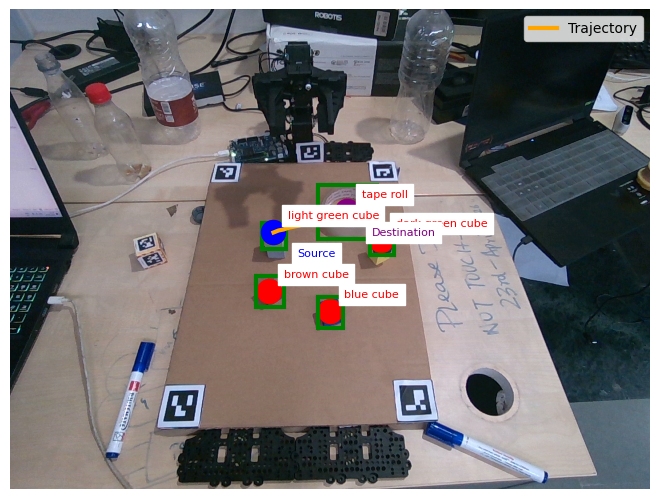

Task: pick_and_place
Moving robot to default position using software interpolation...
Calibrating workspace. Keep markers 0,1,2,3,4 clearly visible...
Calibration progress: 1/8 stable frames
Calibration progress: 2/8 stable frames
Calibration progress: 3/8 stable frames
Calibration progress: 4/8 stable frames
Calibration progress: 5/8 stable frames
Calibration progress: 6/8 stable frames
Calibration progress: 7/8 stable frames
Calibration progress: 8/8 stable frames
Workspace calibration locked.
Origin: [np.float32(-0.043), np.float32(-0.163), np.float32(0.714)]
X axis: [np.float32(0.037), np.float32(0.815), np.float32(-0.578)]
Y axis: [np.float32(0.999), np.float32(-0.019), np.float32(0.038)]
Z axis: [np.float32(0.02), np.float32(-0.579), np.float32(-0.815)]
Workspace calibrated. Capturing a fresh scene for execution...
{
  "task": "pick_and_place",
  "detections": [
    {
      "label": "light green cube",
      "center": {
        "Y": 468,
        "X": 412
      },
      "bounding_

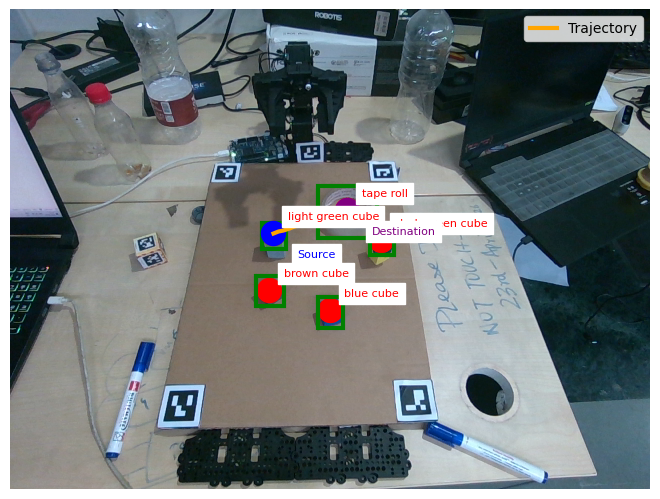

Task: pick_and_place
Pick source -> pixel=(263, 224), depth=0.552m, robot_xyz=(0.205, -0.051, 0.051)
Place destination -> pixel=(337, 201), depth=0.649m, robot_xyz=(0.118, 0.063, -0.001)
Gemini trajectory returned and is plotted for inspection. Motion execution uses source/destination waypoints with vertical approach and retreat.
Executing pick-and-place sequence...
Pick-and-place completed.
Closing port while keeping Dynamixel torque enabled.


In [16]:
TASK_PROMPT = "Pick up the light green cube and place inside the tape roll."
EXECUTE_ROBOT = True
SHOW_DEBUG_PLOT = True

plan = run_prompt_workflow(
    TASK_PROMPT,
    execute_robot=EXECUTE_ROBOT,
    show_plot=SHOW_DEBUG_PLOT,
)
